In [1]:
import warnings
warnings.filterwarnings('ignore')

(Tutorial_Get_cation_pi_interactions)=
# Get cation-pi interactions

*Detecting attributed cation–π geometries and comparing an experimental proposal.*

The default `centroid_distance_angle` / `smarts_5_6` profile reproduces ProLIF 2.2.2's CationPi chemical recognition and distance/angle
criterion. The separately named `centroid_angle_offset` method is a MolSysMT proposal.
Both report geometric evidence, without proving attractive energy. The default
method uses RDKit; installing ProLIF is unnecessary.

:::{versionadded} 1.0.0
:::

:::{admonition} API documentation
:class: dropdown

{func}`molsysmt.interactions.cation_pi.get_cation_pi_interactions` describes the methods,
parameters, original references, adaptations and error conditions.
:::

## Preparing declared chemistry and multiple structures

This controlled benzene/ammonium system has one charged atom and one aromatic ring.
It separates method behavior from chemical assignment. Native conversion preserves
RDKit's bracket-declared hydrogen count; `[NH4+]` remains one indexed atom with four
coordinate-free declared hydrogens, not five coordinate-bearing atoms.
The five structures include rejected geometries and an evaluated empty structure.

In [2]:
import numpy as np
import molsysmt as msm
from molsysmt import pyunitwizard as puw
from rdkit import Chem

molsys = msm.convert(Chem.MolFromSmiles('c1ccccc1.[NH4+]'), to_form='molsysmt.MolSys')
phase = np.arange(6) * np.pi / 3
ring = np.column_stack((.14*np.cos(phase), .14*np.sin(phase), np.zeros(6)))
points = [[0, 0, .35], [.25, 0, .35], [0, 0, 2], [0, 0, -.35], [.1, 0, .35]]
coordinates = np.asarray([np.vstack((ring, point)) for point in points])
molsys.structures.append(coordinates=puw.quantity(coordinates, 'nm'))
print(msm.get(molsys, element='atom', n_explicit_hydrogens=True))

[0, 0, 0, 0, 0, 0, 4]


## Calculating the attributed default

ProLIF's defaults are 0.45 nm and an inclusive acute normal-angle interval of 0–30°.
It matches its cation SMARTS (including amidine/guanidine resonance) and aromatic
5/6-member ring SMARTS. The normal comes from the first two matched atoms relative
to the ring centroid, rather than a least-squares fit. Ring membership retains that
SMARTS order in the result. No offset, planarity or direct-covalent filter is added.

MolSysMT provides single-source scopes, requested frames, sparse results and optional
MIC. It does not reproduce ProLIF's ligand/residue preprocessing or fingerprint
aggregation. Undefined angular geometry yields no candidate. See the original
[ProLIF paper](https://doi.org/10.1186/s13321-021-00548-6) and the versioned links below.

In [3]:
analysis = msm.interactions.cation_pi.get_cation_pi_interactions(molsys, pbc=False)
print(analysis.n_interactions, analysis.occurrence_structures.tolist())
print(analysis.parameters['method_reference'])
print(analysis.measure_units)
print(analysis.relation(0))

3 [0, 3, 4]
{'software': 'ProLIF', 'version': '2.2.2', 'commit': '19f1800218387c49536eb9d3e8cd3044fdb337ee', 'implementation': 'https://github.com/chemosim-lab/ProLIF/blob/19f1800218387c49536eb9d3e8cd3044fdb337ee/prolif/interactions/interactions.py', 'geometry': 'https://github.com/chemosim-lab/ProLIF/blob/19f1800218387c49536eb9d3e8cd3044fdb337ee/prolif/utils.py', 'paper': 'https://doi.org/10.1186/s13321-021-00548-6'}
{'distance': 'nm', 'normal_angle': 'radians', 'offset': 'nm', 'height': 'nm', 'ring_rms_deviation': 'nm', 'ring_max_deviation': 'nm', 'cation_charge': 'e', 'oriented_normal_angle': 'radians'}
{'interaction_type': 'cation_pi', 'participants': [{'role': 'cation', 'atom_indices': array([6])}, {'role': 'ring', 'atom_indices': array([0, 1, 2, 3, 4, 5])}]}


## Inspecting measures and evaluated coverage

`normal_angle` is acute; `oriented_normal_angle` preserves ProLIF's original reported
angle before folding. Distance, offset, height and plane deviations are stored in nm;
angles are radians. ProLIF's plane-deviation measures are diagnostic and do not filter
its observations. A neutral nitrogen recognized through resonance can have
`cation_charge == 0`: this field reports the actual formal charge of the matched atom.

Only accepted occurrences appear in the plot. Evaluated empty structures remain in
coverage, so their absence from the occurrence table is unambiguous.

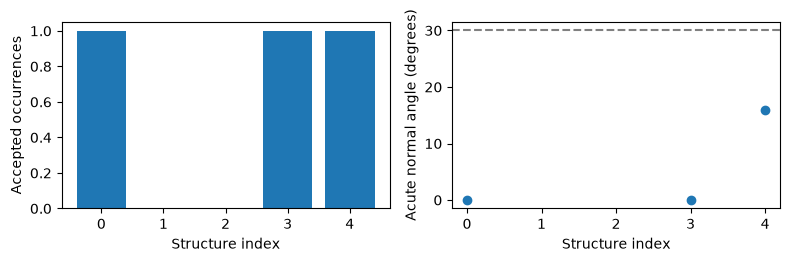

In [4]:
import matplotlib.pyplot as plt
counts = np.bincount(analysis.occurrence_structures, minlength=5)
fig, axes = plt.subplots(1, 2, figsize=(8, 2.6))
axes[0].bar(np.arange(5), counts)
axes[0].set(xlabel='Structure index', ylabel='Accepted occurrences')
axes[1].scatter(analysis.occurrence_structures, np.rad2deg(analysis.measurements['normal_angle']))
axes[1].axhline(30, color='gray', linestyle='--')
axes[1].set(xlabel='Structure index', ylabel='Acute normal angle (degrees)')
fig.tight_layout()
plt.show()

## Selecting structures and querying individual atoms

Repeated requested indices are evaluated once; nonconsecutive indices retain their
source meaning. The detector sorts them. Querying the resulting analysis does not
recalculate chemistry or geometry. IDs are labels and are not structure indices.

In [5]:
selected = msm.interactions.cation_pi.get_cation_pi_interactions(molsys, structure_indices=[4, 0, 2, 4], pbc=False)
print(selected.evaluated_structure_indices.tolist(), selected.occurrence_structures.tolist())
print(analysis.query(atom_indices=6, structure_indices=[4, 0, 4]).to_dict()['occurrence_indices'])
print(analysis.query(structure_indices=2).n_interactions)

[0, 2, 4] [0, 4]
[2 0]
0


## Calculating internal, incident and between scopes

Calculation selections contain complete eligible participants. ProLIF cations are
singleton matched atoms; aromatic rings remain compound participants. A selection
cutting a ring fails explicitly. Completed analyses allow queries by any atom.
`between` requires disjoint selections and accepts either orientation of cation/ring
roles. It does not assume the first atom set contains only cations.

In [6]:
internal = msm.interactions.cation_pi.get_cation_pi_interactions(molsys, selection=[6], pbc=False)
incident = msm.interactions.cation_pi.get_cation_pi_interactions(molsys, selection=[6], selection_mode='incident', pbc=False)
between = msm.interactions.cation_pi.get_cation_pi_interactions(molsys, selection=list(range(6)), selection_2=[6], selection_mode='between', pbc=False)
print(internal.n_interactions, incident.n_interactions, between.n_interactions)
print(analysis.query(atom_indices=[6], mode='across_selection_boundary').n_interactions)
print(analysis.query(atom_indices=list(range(7)), mode='within_selection').n_interactions)

0 3 3
3
3


## Changing cutoffs and angular intervals

Supply physical quantities or unit-bearing strings. A scalar angle sets a maximum
with minimum zero; a two-value quantity specifies both limits. Unit conversion is
independent of your session's preferred units. ProLIF rejects offset or planarity
cutoffs, because they would change its definition.

In [7]:
interval = msm.interactions.cation_pi.get_cation_pi_interactions(molsys, distance_threshold='4.5 angstrom', angle_threshold=puw.quantity([10, 25], 'degrees'), pbc=False)
print(interval.occurrence_structures.tolist())
print(interval.parameters['angle_threshold'])

[4]
{'value': [0.17453292519943295, 0.4363323129985824], 'unit': 'radians'}


## Comparing the separately named proposal

The custom method uses positive formal-charge groups, whole-group arithmetic
centroids, a declared aromatic minimum cycle basis and least-squares planes.
It requires four explicit cutoffs and excludes overlapping/directly covalent pairs.
Those changes can affect chemical memberships as well as geometry. Agreement here
is not evidence of greater scientific accuracy. The comparison remains open in
[uibcdf/molsysmt#271](https://github.com/uibcdf/molsysmt/issues/271).

In [8]:
custom = msm.interactions.cation_pi.get_cation_pi_interactions(molsys, method='centroid_angle_offset', distance_threshold='.45 nm', angle_threshold='30 degrees', offset_threshold='.2 nm', planarity_threshold='.02 nm', pbc=False)
print(analysis.n_interactions, custom.n_interactions)
print(custom.parameters['geometry_rule_version'], custom.parameters['method_reference'])

3 3
cation_centroid_angle_offset@1 None


## Using another molecular-system form

A supported form must provide the required chemical and structural attributes.
RDKit molecules use the ordinary getter route; native MolSys and H5MSM support
projected block delivery. ChemicalStates/Structures without an element inventory
cannot provide the chemistry needed by these detectors. Missing information is an
error rather than permission to infer another method.

In [9]:
rdkit_system = msm.convert(molsys, to_form='rdkit.Mol')
other_form = msm.interactions.cation_pi.get_cation_pi_interactions(rdkit_system, pbc=False, heavy_mode='off')
print(other_form.occurrence_structures.tolist())
columns = msm.interactions.cation_pi.get_cation_pi_interactions(molsys, pbc=False, output_type='molsysmt.InteractionsDict')
restored = msm.convert(columns, to_form='molsysmt.Interactions')
print(restored.n_interactions, type(columns.data['participant_atoms']).__name__)

[0, 3, 4]
3 ndarray


## Retaining periodic images

For MIC, every compound participant must already be whole relative to its anchor.
No internal reconstruction is performed. The stored image shifts the second
participant (the ring) relative to the first (the cation): add `image @ box`, with
box vectors as rows. Missing boxes use nonperiodic geometry. A split ring fails.
Reconstruct a bonded component with the general PBC tools before detection when
needed, rather than hiding this operation in the detector.

In [10]:
periodic = msm.copy(molsys)
box = np.eye(3) * 2
xyz = coordinates.copy()
xyz[:, :6] += box[0]
msm.set(periodic, coordinates=puw.quantity(xyz, 'nm'), box=puw.quantity(np.repeat(box[None], 5, axis=0), 'nm'))
images = msm.interactions.cation_pi.get_cation_pi_interactions(periodic, structure_indices=[0], pbc=True)
print(images.image_vectors.tolist())
observed_ring = xyz[0, :6].mean(axis=0) + images.image_vectors[1] @ box
print(np.linalg.norm(xyz[0, 6] - observed_ring), images.measurements['distance'][0])

[[0, 0, 0], [-1, 0, 0]]
0.35 0.35


## Working with a declared protein state

This bundled Trp-Cage ensemble supplies realistic coordinates. The charge assignments
below declare a modeling state: positive N-terminus/Lys8/Arg16 and negative Asp9/
C-terminus, with the remaining formal charges zero. They are not measured protonation
or inferred by the detector. RDKit reads the connectivity and aromatic chemistry;
this preparation is separate from ProLIF geometric observation.

In [11]:
protein = Chem.MolFromPDBFile(str(msm.systems['Trp-Cage']['1l2y.pdb']), removeHs=False)
charges = {0: 1, 143: 1, 164: -1, 236: 1, 298: -1}
for atom in protein.GetAtoms():
    charge = charges.get(atom.GetIdx(), 0)
    atom.SetFormalCharge(charge)
    if charge < 0:
        atom.SetNoImplicit(True)
Chem.SanitizeMol(protein)
molsys_protein = msm.convert(protein, to_form='molsysmt.MolSys')
protein_analysis = msm.interactions.cation_pi.get_cation_pi_interactions(molsys_protein, pbc=False)
print(protein_analysis.n_interactions, len(protein_analysis.evaluated_structure_indices))

0 38


## Choosing execution and attaching an analysis

`heavy_mode='force'` uses a form's declared streamed coordinate route. All methods
retain their accepted sparse result in RAM; blocks do not reclaim source coordinates
already owned by the caller. Working estimates do not bound process RSS. Excessive
matching, candidates or output raise rather than returning a truncated analysis.

Calculations never attach automatically. Preserve previous named analyses with an
explicit assignment. The executed persistence recipe demonstrates native and file
blocks, extraction, typed interchange and a standalone interactions layer.

In [12]:
with msm.configure.context(chunk_size=2):
    blocked = msm.interactions.cation_pi.get_cation_pi_interactions(molsys, pbc=False, heavy_mode='force')
print(blocked.execution_records[0]['details']['execution_chunks'])
molsys.interactions = {**molsys.interactions, 'cation_pi': analysis}
print(list(molsys.interactions))

3
['cation_pi']


## Applying Mol* geometry to declared features

`molstar_geometry` uses a 0.60 nm centroid distance and 0.20 nm lateral offset,
with the first three aromatic-basis atoms defining a triangle normal. There is no
angle or planarity filter. Our formal-charge centers supply participants; Mol*'s
residue/valence-model feature discovery and contact refinement are not replicated.
This is an attributed geometric profile, not complete Mol* detector parity.

In [13]:
molstar = msm.interactions.cation_pi.get_cation_pi_interactions(
    molsys, method='centroid_distance_offset', profile='three_atom_plane', pbc=False)
print(molstar.occurrence_structures.tolist(), molstar.parameters['method_reference'])

[0, 3, 4] {'software': 'Mol*', 'commit': '4807179589f43c20f38d689e4acbc3fc8590df14', 'implementation': 'https://github.com/molstar/molstar/blob/4807179589f43c20f38d689e4acbc3fc8590df14/src/mol-model-props/computed/interactions/charged.ts', 'paper': 'https://doi.org/10.1093/nar/gkab314'}


:::{seealso}
:class: dropdown

- {ref}`Cookbook_Saving_cation_pi_interactions` — named analyses and H5MSM round trips.
- {ref}`Tutorial_Get_substructure_matches` — reusable chemical matching.
- {ref}`Tutorial_Get_charge_centers` and {ref}`Tutorial_Get_aromatic_rings` — custom participants.
- {ref}`Tutorial_Get_least_squares_plane` — fitting general planes.
:::

## Retaining scientific attribution

The analysis records `method`, `profile`, `method_definition` and a compact
bibliography in `analysis.parameters['attribution']`. Bibliographic roles distinguish
the scientific criterion, reference implementation and software actually executed.
These records survive typed conversion and H5MSM 0.5 persistence. Loading the file
does not claim a new calculation. With optional Ackredit installed, completed
calculations also contribute to the caller's workflow session. No hooks, online DOI
lookup or journal are enabled by MolSysMT.
See {ref}`Methods and attribution <user-tools-interactions-attribution>` for the
canonical method/profile table, compatible aliases and optional reporting example.


In [14]:
print(analysis.parameters['method'], analysis.parameters['profile'])
print([(item['title'], item['roles']) for item in analysis.parameters['attribution']['items']])


centroid_distance_angle smarts_5_6
[('ProLIF: a library to encode molecular interactions as fingerprints', ['reference_implementation']), ('MolSysMT', ['executed_software']), ('RDKit: Open-source cheminformatics', ['executed_software'])]
